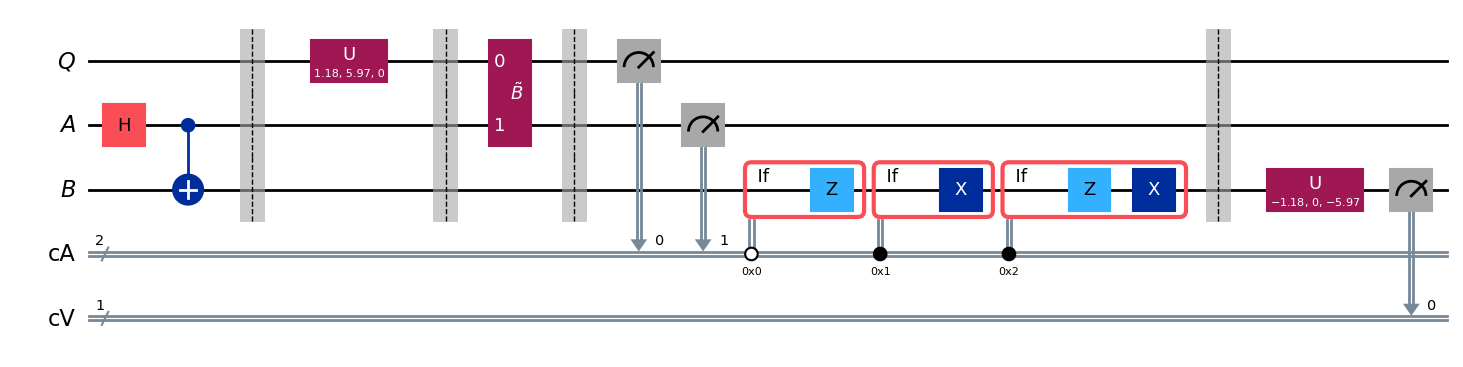

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
from math import pi
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import SGate, XGate, UnitaryGate, IGate
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_cloud",
            token="", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
            instance='') 
service.backends()

# ----------------- B Gate -----------------
c1 = np.pi/2
c2 = np.pi/4

theta1 = (c1 - c2)
theta2 = (c1 + c2)

U = np.array([
    [np.cos(theta1), 0, 0, -1j*np.sin(theta1)],
    [0, np.cos(theta2), -1j*np.sin(theta2), 0],
    [0, -1j*np.sin(theta2), np.cos(theta2), 0],
    [-1j*np.sin(theta1), 0, 0, np.cos(theta1)]
])

B = Operator(U)

def b_tilde(B_op: Operator):
    S = SGate().to_matrix()
    X = XGate().to_matrix()

    return UnitaryGate(np.kron(S, X) @ B_op.data @ np.kron(S, X), label=r'$\tilde{B}$')
u_final = b_tilde(B)
u_final.label=r'$\tilde{B}$'

# ----------------- Quantum + Classical Registers -----------------
secret = QuantumRegister(1, "Q")
Alice  = QuantumRegister(1, "A")
Bob    = QuantumRegister(1, "B")

cA = ClassicalRegister(2, "cA")  # Alice outcome (2 bits combined automatically)
cV = ClassicalRegister(1, "cV")  # verification bit

qc = QuantumCircuit(secret, Alice, Bob, cA, cV)

# ----------------- Create Bell Pair -----------------
qc.h(Alice)
qc.cx(Alice, Bob)
qc.barrier()

# ----------------- Secret State -----------------
np.random.seed(42)
theta = np.random.uniform(0.0, np.pi)
varphi = np.random.uniform(0.0, 2*np.pi)
qc.u(theta, varphi, 0.0, secret)
qc.barrier()

# ----------------- Apply B̃ -----------------
qc.unitary(u_final, [secret[0], Alice[0]], label=r'$\tilde{B}$')
qc.barrier()

# ----------------- Alice Measures -----------------
qc.measure(secret, cA[0])
qc.measure(Alice,  cA[1])

# ==========================================================
#    B̃ Correction Logic (now legal because cA is integer)
# ==========================================================
# cA binary mapping:   |secret Alice⟩
# values:               00  01  10  11

with qc.if_test((cA, 0)):     # 00 → Z
    qc.z(Bob)

with qc.if_test((cA, 1)):     # 01 → X
    qc.x(Bob)

with qc.if_test((cA, 2)):     # 10 → ZX
    qc.z(Bob)
    qc.x(Bob)
qc.barrier()

# ----------------- Verification -----------------
qc.u(theta, varphi, 0.0, Bob).inverse()
qc.measure(Bob, cV[0])

qc.draw("mpl")


{'0 00': 1016, '0 11': 1005, '0 10': 1042, '0 01': 1033}
ibm_fez
Transpiled Circuit:


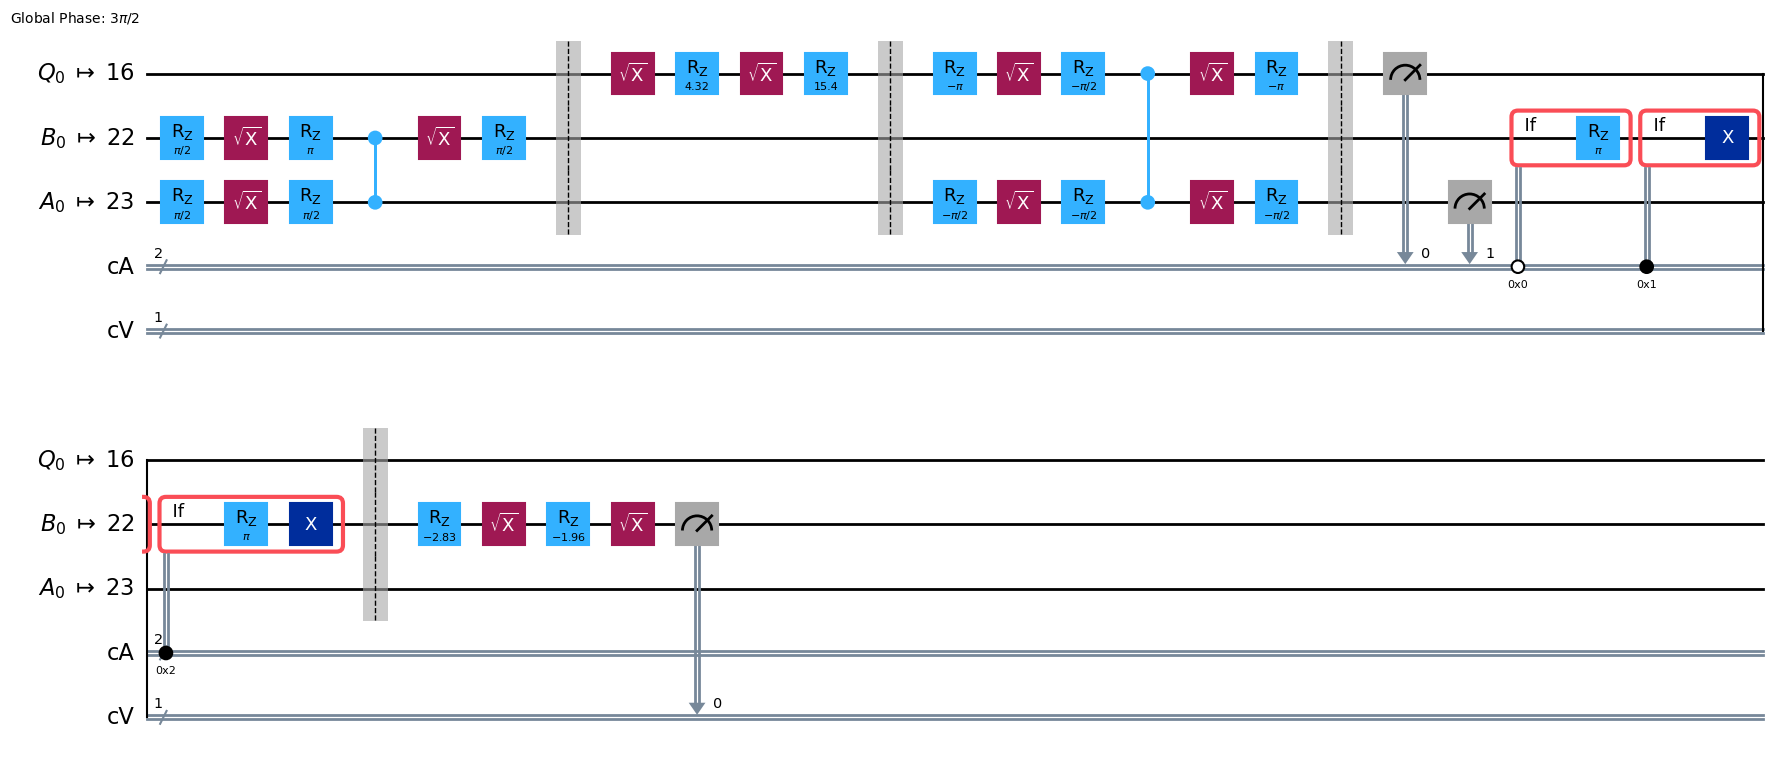

In [ ]:
backend = AerSimulator()
result = backend.run(qc, shots=4096).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(backend.name)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
print("Transpiled Circuit:")
qc_isa.draw(output="mpl", idle_wires=False)



{'000': 977, '100': 48, '001': 997, '010': 926, '011': 913, '111': 62, '101': 91, '110': 82}


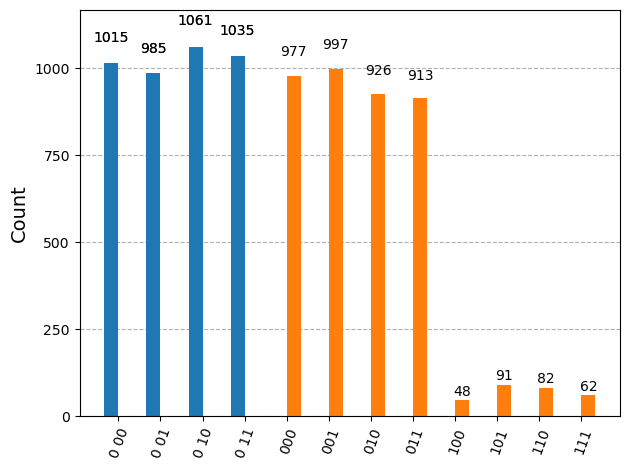

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler 
sampler = Sampler(mode=backend)


job = sampler.run([qc_isa])
res = job.result()
pub = res[0]
counts1 = pub.join_data().get_counts()

plot_histogram(
    [counts, counts1],
    legend=["Simulator", "Backend"]
)


print(counts1)
plot_histogram([counts, counts1])